Implementing Sachdev definition of thermal correlators. Following much of the exact solution.

In [97]:
import numpy as np
import matplotlib.pyplot as plt
from numpy import sqrt, exp, cos, sin, log, tanh,pi
def Dn(n, g, T):
    phi = np.linspace(0, 2 * pi, 1000)
    z = np.exp(1j * phi)
    pf = np.sqrt((1 - g * z) / (1 - g / z))
    arg = np.sqrt((1 - g * z) * (1 - g / z)) / T
    integrand = pf * np.tanh(arg) * z ** (-n)
    return np.real(np.sum(integrand) / len(phi))


In [64]:
eps = 10e-10
print(f"This notebook {Dn(1,1-eps,eps)}")
print(f"Known result {ecc.Dn(1)}")

This notebook -0.6344594382658232
Known result -0.6366197723675814


In [28]:
import sys
sys.path.append("../../src")
import equilibrium_critical_correlations as ecc

In [65]:
import sys
import os
sys.path.append("../../../src/")
#Imports
import scipy as sp
import numpy.linalg as la
from collections import Counter
import kblock_ising_model as kb

##Personal Imports##

from numpy import pi, cos, sin, exp, log, sqrt, array


def sigma_general(indices,g,T):
    def remove_duplicates_in_pairs(vec):
      unique_vals, counts = np.unique(vec, return_counts=True)
      filtered_vals = unique_vals[counts % 2 != 0]
      return filtered_vals.tolist()
    #Sigma matrices on different sites commute
    indices = np.sort(indices)
    #Remove any duplicates as sigma_x^2 = 1
    indices = remove_duplicates_in_pairs(indices)
    #Bs sit on odd sites
    odd_sites = np.array(indices[::2])
    #As site on even sites
    even_sites= np.array(indices[1::2])
    #Get string lengths
    JW_string_lengths = even_sites-odd_sites
    #Sum of string lengths is size of matrix needed
    N = sum(JW_string_lengths)
    #Fill in indices for strings
    R = []
    for i in range(0, len(indices), 2):
        start = indices[i]
        end = indices[i+1]
        R.extend(range(start, end+1))

    A_coords = [x for x in R if x not in odd_sites]
    B_coords = [x for x in R if x not in even_sites]
    C = np.zeros((N,N))
    for nx in range(N):
        for ny in range(N):
            Bx = B_coords[nx]
            Ay = A_coords[ny]
            Nd = Bx-Ay+1
            C[nx,ny] = Dn(Nd,g,T)
    return np.linalg.det(C)

#Typical Pn function
def P_n(n,g,T,even = True):
    """
    P_n scales directly with the number of terms since even small odd sigma correlations need larger support to calcualte.
    Taking out odd terms works to make easier, but scaling is still 2^n.
    Minor improvements can still be had though.
    """
    #For most cases we use periodic boundary conditions
    #That said, watch out for this definition of indices
    indices = [i for i in range(0,n)]
    terms = kb.all_combinations(indices)

    ###
    x_c = []
    for a in terms[1:]:
      
        a = np.array(a)
        x_c.append(tuple(a - a[0]))  # convert to tuple for hashing
    counter = Counter(x_c)

    # Extract vecs and counts as separate arrays/lists
    vecs = list(counter.keys())
    counts = np.array(list(counter.values()))

    ##
    dat = []

    for term in range(len(vecs)):
        indices = vecs[term]
        degen = counts[term]

        if len(indices)%2 == 1:
            if even ==True:
                dat.append(0)
            else:
                constant = len(k)//2
                indices = list(indices) + [x + constant for x in indices]
                dat.append(np.sqrt(np.abs(sigma_general(indices,g,T)))*degen)
        else:
            dat.append(sigma_general(indices,g,T)*degen)
    dat.append(1)
    #All terms have equal weight. 
    return np.sum(dat)/2**n


#P_n correlations do not calculate connected correlator at all
def P_n_correlations(n,l,g,T, even = True):
    #Term 1 
    indices = [i for i in range(0,n)]
    #Term 2 
    indices +=[i for i in range(n+l-1,2*n+l-1)]
    terms = kb.all_combinations(indices)
   # print(terms)
     ###
    x_c = []
    for a in terms[1:]:
      
        a = np.array(a)
        x_c.append(tuple(a - a[0]))  # convert to tuple for hashing
    counter = Counter(x_c)

    # Extract vecs and counts as separate arrays/lists
    vecs = list(counter.keys())
    counts = np.array(list(counter.values()))
    #
    dat = []
    for term in range(len(vecs)):
        indices = vecs[term]
        degen = counts[term]

        if len(indices)%2 == 1:
            if even ==True:
                dat.append(0)
            else:
                constant = len(k)//2
                indices = list(indices) + [x + constant for x in indices]
                dat.append(np.sqrt(sigma_general(indices,g,T))*degen)
        else:
            dat.append(sigma_general(indices,g,T)*degen)
    dat.append(1)
    #All terms have equal weight. 

    return np.sum(dat)/2**(2*n)#,terms


In [150]:
from tqdm import tqdm
T = 1.5
g=1-eps
dat=[]
dat2=[]
X = np.arange(1,25)
n = 5
for j in X:
    indices = [i for i in range(0,n)]
    indices+=[i+j for i in range(n,2*n)]
    dat.append(sigma_general(indices,g,eps))#-sigma_general([0,1],g,eps)**2)
    dat2.append(sigma_general(indices,1-eps,T))#-sigma_general([0,1],g,T)**2)


(1.0, 24.0)

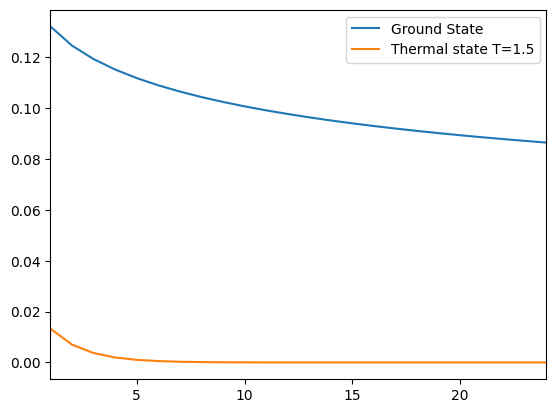

In [151]:
plt.plot(X,dat,label="Ground State")
plt.plot(X,dat2,label=f"Thermal state T={T}")
plt.legend()
plt.xlim(X[0],X[-1])
#plt.xlim(.1,T[-1])
#plt.loglog()
#plt.yscale("log")